# Example Usage

This notebook walks through every plot function using two sets of TextGrid files.
They come from the same dataset: one alignment set is produced by [MFA](https://github.com/MontrealCorpusTools/Montreal-Forced-Aligner) and the other by [W2TG](https://github.com/pkadambi/Wav2TextGrid).

## 1. Imports

In [1]:
import glob

from alignment_comparison_plots import (
    plot_phoneme_counts,
    plot_phoneme_overlap,
    plot_phoneme_overlap_rate,
    plot_phoneme_pair_scatter,
)

## 2. Configure paths and shared kwargs

Point `paths_a` and `paths_b` at the two alignment sets you want to compare.
Files are matched by **basename**, so both directories should contain files with identical names.

| Parameter | Description |
|---|---|
| `paths_a` / `paths_b` | Lists of `.TextGrid` file paths — one list per aligner |
| `label_a` / `label_b` | Human-readable names shown in chart titles and legends |
| `tier_name` | Name of the TextGrid interval tier to read (default: `"phones"`) |
| `aggregate_emphasis` | When `True`, strips trailing digits so `AH0`, `AH1`, `AH2` all count as `AH` |
| `theme` | Optional `(color_a_or_low, color_b_or_high, background)` hex strings to override the default dark palette |

> **Note:** The library does not validate paths or data pairs. Validate your path lists before plotting; the right checks depend on your use case. The cell below shows a minimal example.

In [2]:
# ── Edit these paths to point at your own TextGrid directories ──────────────
DATASET = "/Users/beckettfrey/.voxkit/datasets/20260310_144753_819272/"
ALIGNMENT_A = f"{DATASET}/alignments/20260310_144925_055142/textgrids/cache"
ALIGNMENT_B = f"{DATASET}/alignments/20260310_144806_088416/textgrids/cache"
# ────────────────────────────────────────────────────────────────────────────

paths_a = glob.glob(f"{ALIGNMENT_A}/*/*.TextGrid")
paths_b = glob.glob(f"{ALIGNMENT_B}/*/*.TextGrid")

print(f"Set A: {len(paths_a)} files")
print(f"Set B: {len(paths_b)} files")

if len(paths_a) != len(paths_b):
    print("Warning: The two sets have different numbers of files. Make sure they are aligned properly.")
    
speakers_a = set(p.split("/")[-2] for p in paths_a)
speakers_b = set(p.split("/")[-2] for p in paths_b)

print(f"Speakers in A: {len(speakers_a)}")
print(f"Speakers in B: {len(speakers_b)}")

if speakers_a != speakers_b:
    print("Warning: The two sets have different speakers. Make sure they are aligned properly.")

Set A: 181 files
Set B: 181 files
Speakers in A: 3
Speakers in B: 3


In [3]:
# All plot functions accept these common kwargs.
# Build them once and unpack with ** into each call below.
SHARED = dict(
    paths_a=paths_a,
    paths_b=paths_b,
    label_a="W2TG Reference",
    label_b="MFA Hypothesis",
    aggregate_emphasis=True,  # strip stress markers: AH1 → AH
)

## 3. Phoneme counts

Side-by-side bar chart showing how many times each phoneme appears in each alignment set.
Useful for verifying that both aligners produce similar phoneme distributions.

qt.qpa.fonts: Populating font family aliases took 10 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost. 
This plugin does not support propagateSizeHints()


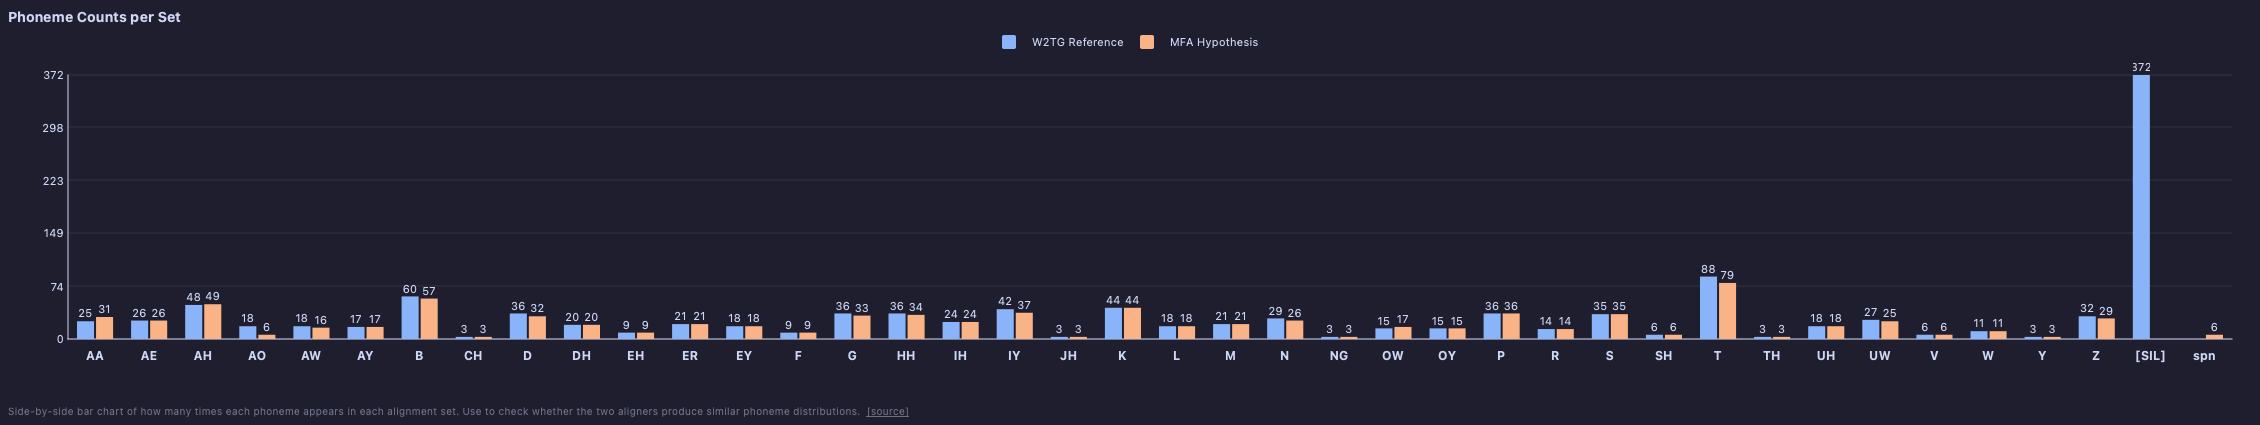

In [11]:
plot_phoneme_counts(**SHARED, save_png="../plots/plot_phoneme_counts.png", exec_=False)

## 4. Phoneme overlap (mean IoU)

For each reference interval the best same-label hypothesis interval is scored with IoU.
Bars are sorted left→right by ascending mean IoU and coloured red (poor) → green (perfect).

qt.qpa.fonts: Populating font family aliases took 11 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost. 
This plugin does not support propagateSizeHints()


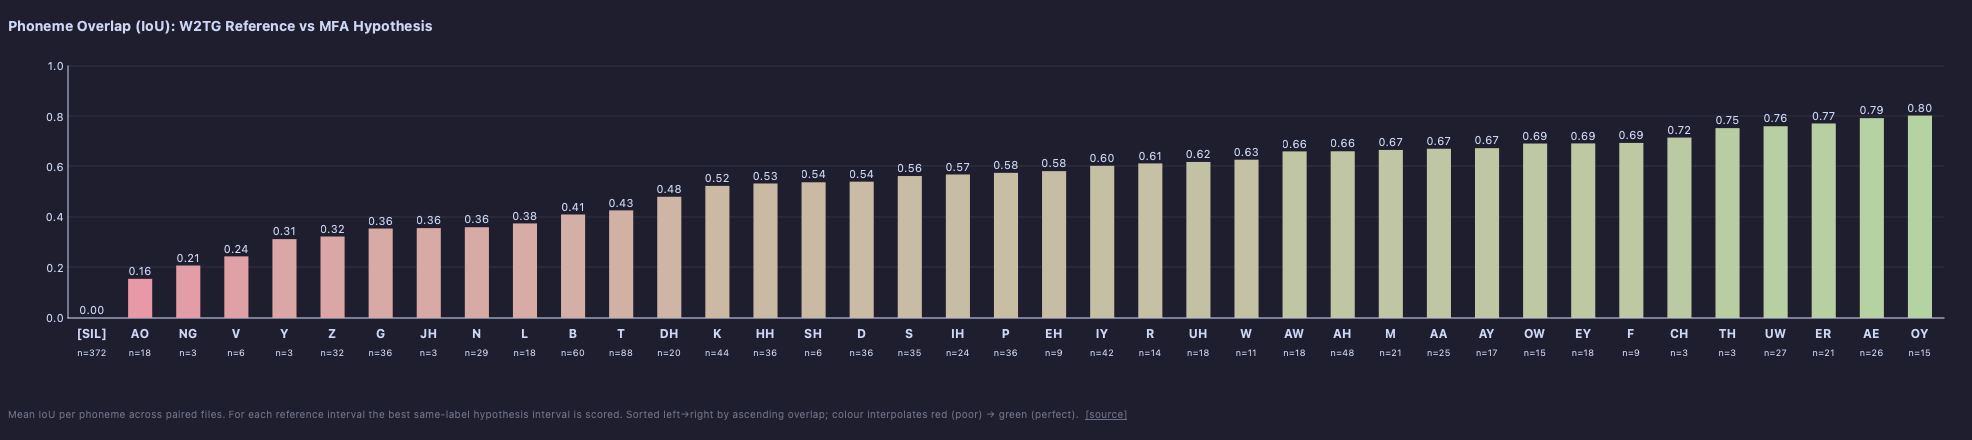

In [12]:
plot_phoneme_overlap(**SHARED, save_png="../plots/plot_phoneme_overlap.png", exec_=False)

## 5. Phoneme overlap rate

Percentage of reference intervals whose best same-label hypothesis match has IoU ≥ `threshold`.
Adjust `threshold` to tighten or loosen what counts as a successful match.

qt.qpa.fonts: Populating font family aliases took 11 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost. 
This plugin does not support propagateSizeHints()


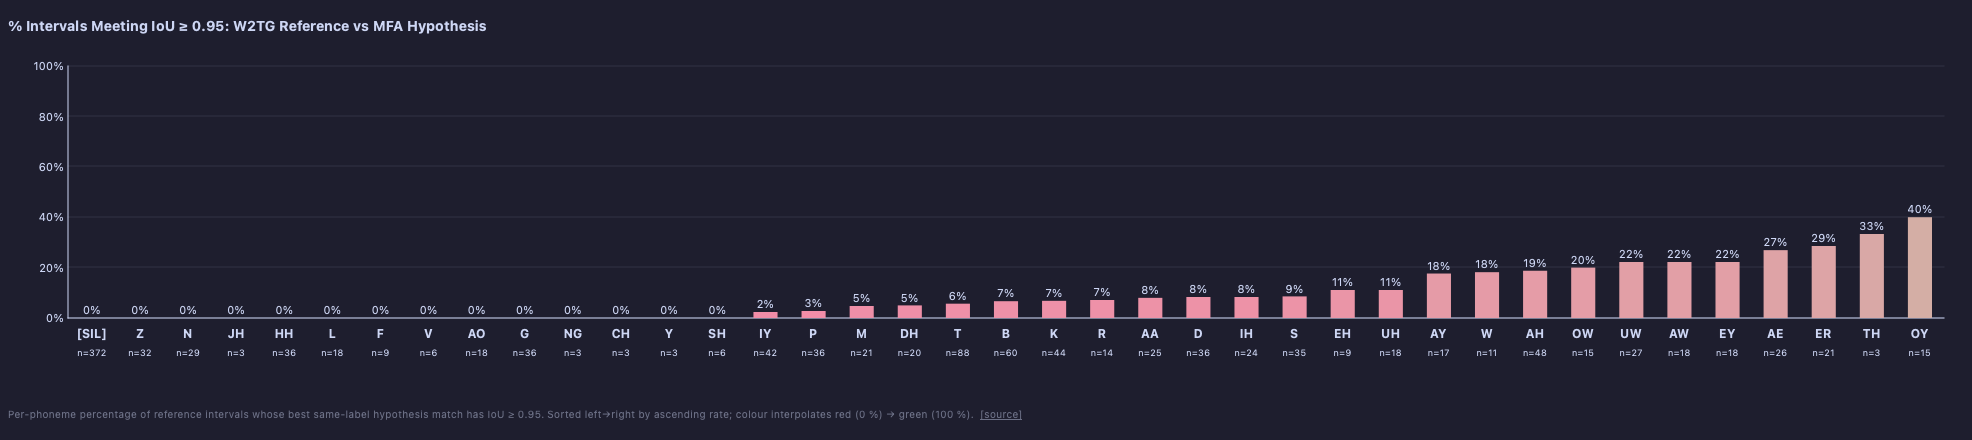

In [13]:
plot_phoneme_overlap_rate(**SHARED, threshold=0.95, save_png="../plots/plot_phoneme_overlap_rate.png", exec_=False)

## 6. Phoneme pair scatter

Grid of (reference phoneme, hypothesis phoneme) pairs.
Bubble size ∝ observation count; colour = mean IoU.
On-diagonal bubbles indicate label agreement; off-diagonal bubbles indicate substitutions.

qt.qpa.fonts: Populating font family aliases took 11 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost. 
This plugin does not support propagateSizeHints()


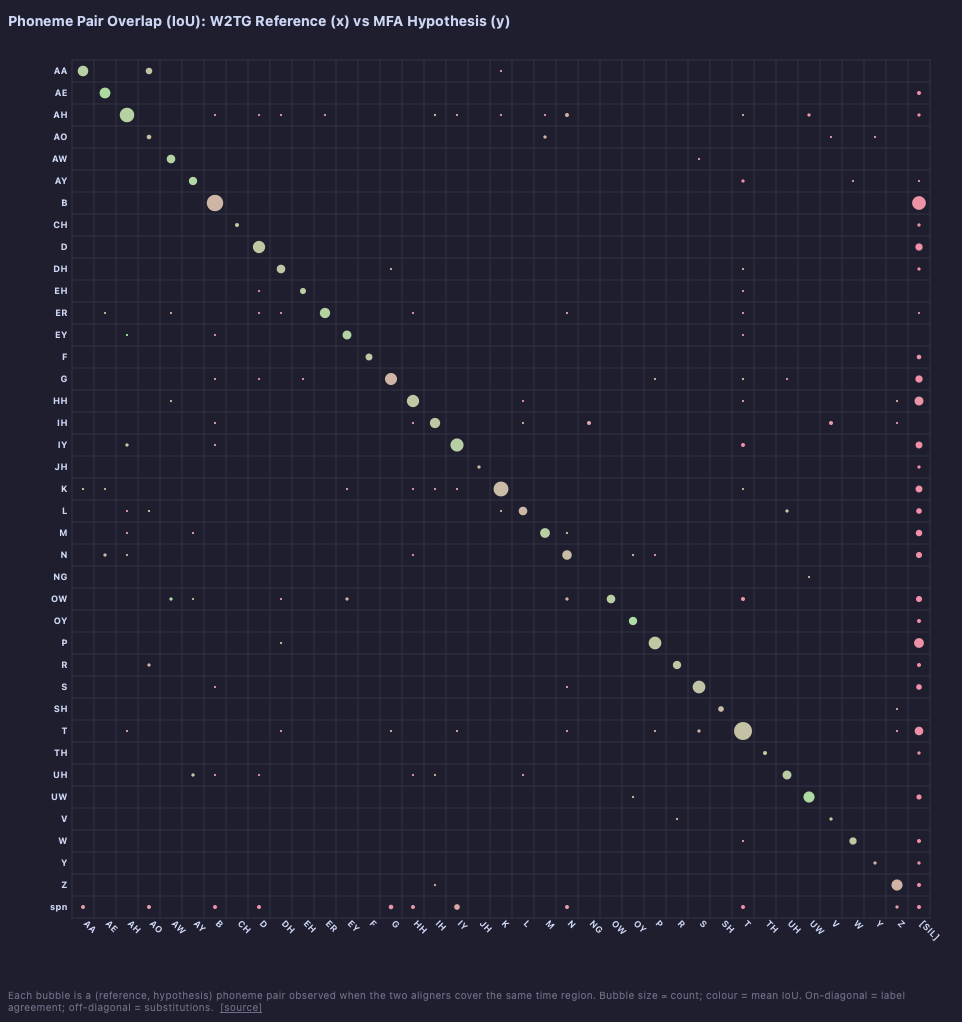

In [14]:
plot_phoneme_pair_scatter(**SHARED, save_png="../plots/plot_phoneme_pair_scatter.png", exec_=False)

## 7. Custom themes

Every plot function accepts an optional `theme` tuple of three hex colour strings.

- For `plot_phoneme_counts`: `(color_a, color_b, background)`
- For the three overlap plots: `(low_color, high_color, background)` where each bar/bubble
  interpolates from `low_color` (IoU = 0) to `high_color` (IoU = 1)

qt.qpa.fonts: Populating font family aliases took 12 ms. Replace uses of missing font family "Sans Serif" with one that exists to avoid this cost. 
This plugin does not support propagateSizeHints()


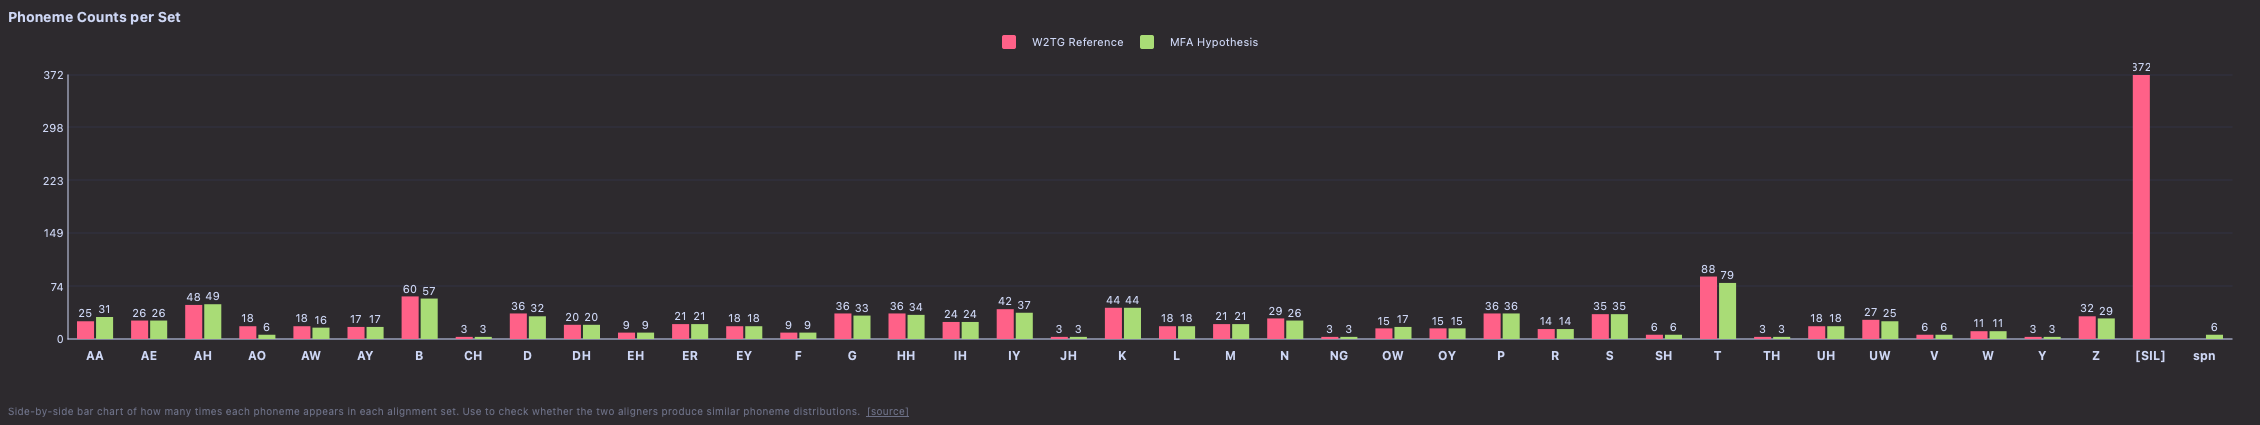

In [15]:
MONOKAI = ("#ff6188", "#a9dc76", "#2d2a2e")  # low/A, high/B, background

plot_phoneme_counts(**SHARED, theme=MONOKAI, save_png="../plots/plot_phoneme_counts_monokai.png", exec_=False)